# Classical Time-Series Forecasting (ARIMA / SARIMA)
## Smart Energy Consumption Prediction System — Member 2

**Scope (Time-Series Forecasting & Regression group — Member 2 responsibilities):**
- Implement ARIMA
- Implement SARIMA (if clear seasonality is present)
- Tune suitable parameters
- Generate future consumption forecasts
- Evaluate and compare performance against the regression models (Member 1) and the final model selection (Member 3)

This notebook uses the reusable functions in `src/classical_timeseries.py` so the
same logic can be re-run from the command line or imported by Member 3's
comparison notebook.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from classical_timeseries import (
    load_feature_engineered_data,
    resample_series,
    chronological_split,
    split_summary,
    adf_test,
    find_differencing_order,
    seasonal_decomposition,
    seasonality_strength,
    fit_arima,
    fit_sarima,
    forecast_series,
    evaluate_forecast,
    high_demand_error_analysis,
    residuals,
    save_model,
    save_predictions,
    save_metrics,
    TARGET_COL,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Data Preparation

Load Member 1's feature-engineered dataset (`data/feature_engineered_dataset.csv`)
and confirm the target variable and forecasting setup.

**Target variable:** `Global_active_power` (household global active power, in kW).

**Note on frequency:** the raw dataset is at 1-minute resolution (~2M rows,
Dec 2006 – Nov 2010). Fitting ARIMA/SARIMA at 1-minute resolution over the
full series is not computationally realistic within the project deadline, so
this notebook resamples to an **hourly** series before fitting classical
models. This is a deliberate, documented choice — Member 1's regression
models can still use the raw-frequency engineered features; only the
classical time-series models here operate on the resampled series.

In [2]:
DATA_PATH = "../data/feature_engineered_dataset.csv"

df = load_feature_engineered_data(DATA_PATH)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Timestamp,...,Quarter,Weekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingStd_24,Difference,PctChange,Peak
0,16/12/2006,20:12:00,3.400,0.140,233.62,14.4,0.0,0.0,17.0,16/12/2006 20:12:00,...,4,1,3.410,3.380,4.216,3.286333,0.083777,-0.010,-0.002933,1
1,16/12/2006,20:13:00,3.400,0.140,233.64,14.4,0.0,0.0,17.0,16/12/2006 20:13:00,...,4,1,3.400,3.404,5.360,3.286167,0.083537,0.000,0.000000,1
2,16/12/2006,20:14:00,3.388,0.140,233.26,14.4,0.0,0.0,16.0,16/12/2006 20:14:00,...,4,1,3.400,3.378,5.374,3.286583,0.084038,-0.012,-0.003529,1
3,16/12/2006,20:15:00,3.370,0.086,233.90,14.4,0.0,0.0,17.0,16/12/2006 20:15:00,...,4,1,3.388,3.388,5.388,3.285833,0.083170,-0.018,-0.005313,1
4,16/12/2006,20:16:00,3.332,0.000,233.68,14.2,0.0,0.0,17.0,16/12/2006 20:16:00,...,4,1,3.370,3.376,3.666,3.284000,0.081565,-0.038,-0.011276,1


In [3]:
print(f"Rows: {len(df):,}")
print(f"Date range: {df['Datetime'].min()} -> {df['Datetime'].max()}")
print(f"Target column: {TARGET_COL}")
df[TARGET_COL].describe()

Rows: 2,047,446
Date range: 2006-12-16 20:12:00 -> 2010-11-26 21:02:00
Target column: Global_active_power


count    2.047446e+06
mean     1.091045e+00
std      1.056945e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64

Hourly observations: 34,142


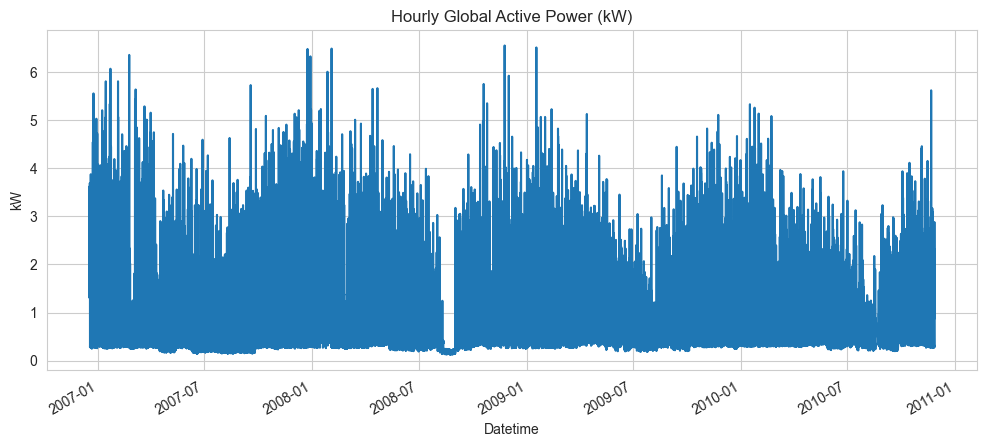

In [4]:
# Resample the 1-minute series to hourly means for classical TS modelling
series = resample_series(df, target_col=TARGET_COL, freq="h")

print(f"Hourly observations: {len(series):,}")
series.plot(title="Hourly Global Active Power (kW)", ylabel="kW")
plt.show()

### Train / Validation / Test split

**IMPORTANT — sync with Member 1 and Member 3:** the split below uses a
70 / 15 / 15 chronological split by default. Before finalizing results,
confirm the exact split fractions (or cutoff timestamps) with the rest of
the team so every model in the final comparison table is evaluated on the
identical test window. Update `TRAIN_FRAC` / `VAL_FRAC` below if the team
agrees on different values.

In [5]:
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

train, val, test = chronological_split(series, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC)

split_info = split_summary(train, val, test)
for name, bounds in split_info.items():
    print(f"{name:>5}: {bounds['n_obs']:>6} obs  |  {bounds['start']}  ->  {bounds['end']}")

train:  23899 obs  |  2006-12-16 20:00:00  ->  2009-09-13 12:00:00
  val:   5121 obs  |  2009-09-13 13:00:00  ->  2010-04-18 15:00:00
 test:   5122 obs  |  2010-04-18 16:00:00  ->  2010-11-26 21:00:00


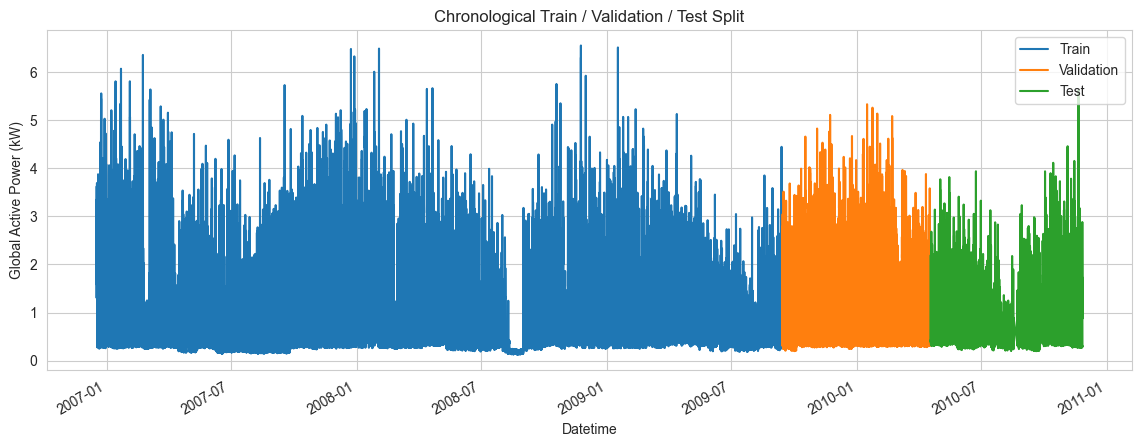

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
train.plot(ax=ax, label="Train")
val.plot(ax=ax, label="Validation")
test.plot(ax=ax, label="Test")
ax.set_title("Chronological Train / Validation / Test Split")
ax.set_ylabel("Global Active Power (kW)")
ax.legend()
plt.show()

## 2. Stationarity Check (ADF Test)

ARIMA assumes a stationary series. We test the training series with the
Augmented Dickey-Fuller test and determine the minimal differencing order
`d` that achieves stationarity (p-value < 0.05).

In [7]:
adf_result = adf_test(train, name="train (original)")
adf_result

D:\Github project\Smart-Energy-Consumption-Prediction-System\notebooks\../src\classical_timeseries.py:139: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


{'name': 'train (original)',
 'adf_statistic': -11.115053991069068,
 'p_value': 3.5803878269027525e-20,
 'n_lags': 48,
 'n_obs': 23850,
 'critical_values': {'1%': -3.4306242140023127,
  '5%': -2.8616611940292076,
  '10%': -2.5668345080829256},
 'is_stationary': True}

In [8]:
d = find_differencing_order(train, max_d=2)
print(f"Selected differencing order d = {d}")

if d > 0:
    diffed = train.diff(d).dropna()
    adf_test(diffed, name=f"train (differenced, d={d})")

Selected differencing order d = 0


D:\Github project\Smart-Energy-Consumption-Prediction-System\notebooks\../src\classical_timeseries.py:139: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


## 3. Seasonality Check

Household electricity consumption typically has a strong **daily** cycle
(period = 24 for hourly data). We decompose the training series to confirm
this and to decide between plain ARIMA and SARIMA.

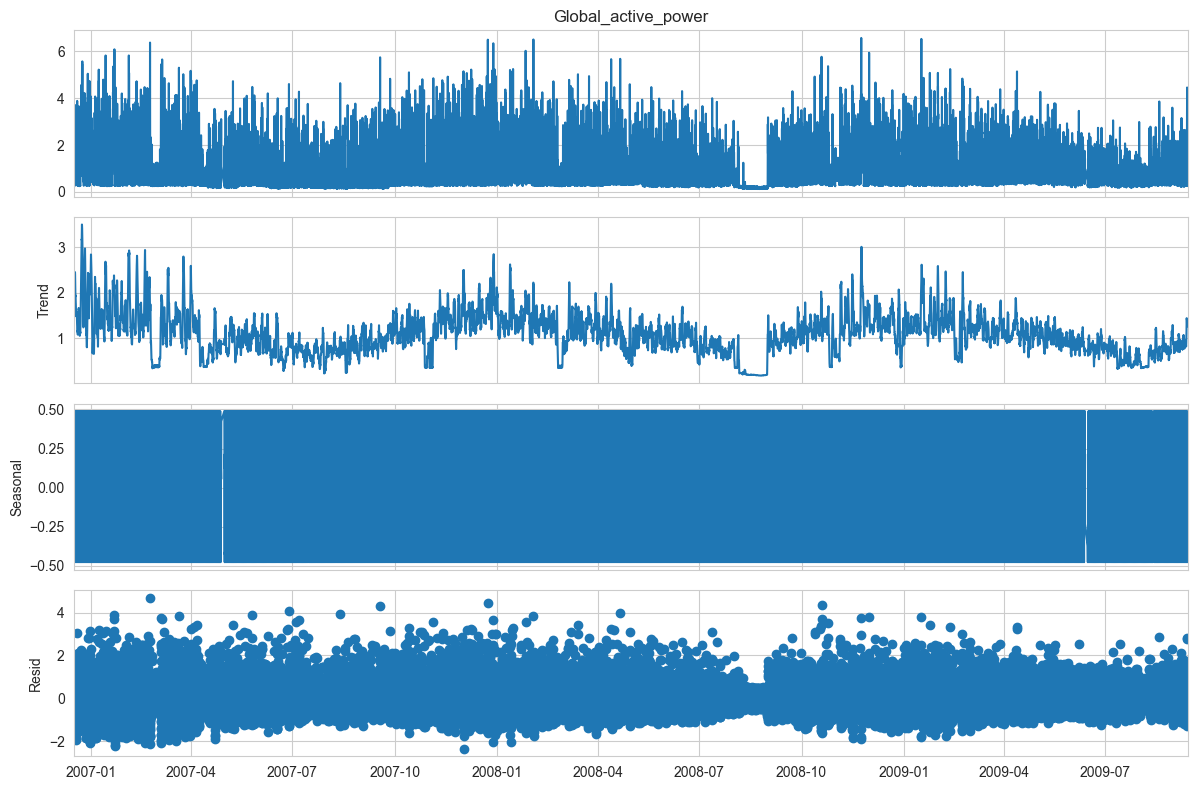

In [9]:
SEASONAL_PERIOD = 24  # hourly data, daily cycle

decomposition = seasonal_decomposition(train, period=SEASONAL_PERIOD)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [10]:
strength = seasonality_strength(decomposition)
print(f"Seasonality strength (F_s): {strength:.3f}")

SEASONALITY_THRESHOLD = 0.30
use_sarima = strength >= SEASONALITY_THRESHOLD

print(f"Decision: {'Use SARIMA' if use_sarima else 'Use plain ARIMA'} "
      f"(threshold = {SEASONALITY_THRESHOLD})")

Seasonality strength (F_s): 0.127
Decision: Use plain ARIMA (threshold = 0.3)


## 4. ACF / PACF (parameter guidance)

Used as a sanity check / starting range alongside the automatic search in
Section 5 — not a hard requirement, since `auto_arima` performs a stepwise
AIC-based search, but useful for the report to justify the chosen orders.

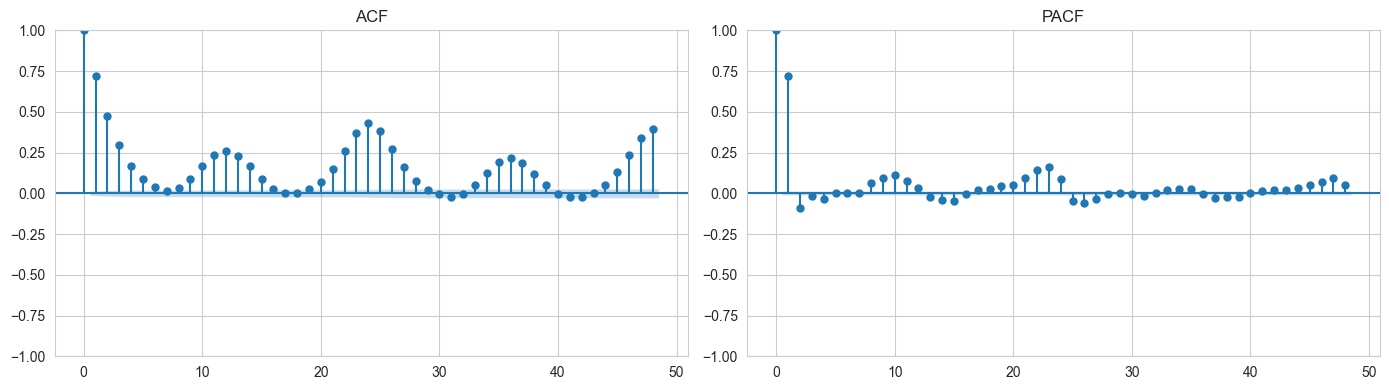

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series_for_acf = train.diff(d).dropna() if d > 0 else train

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_for_acf, ax=axes[0], lags=48)
plot_pacf(series_for_acf, ax=axes[1], lags=48)
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

## 5. Model Fitting

### 5.1 ARIMA (non-seasonal)

In [12]:
arima_model = fit_arima(train, max_p=5, max_q=5, trace=True)
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=50430.601, Time=2.98 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=50340.612, Time=1.94 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=50307.133, Time=3.70 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=50428.601, Time=0.73 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=20.02 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=49543.426, Time=6.18 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=39.51 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=47265.985, Time=24.29 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=56.97 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=38.35 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=44.07 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=47264.045, Time=6.38 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=49541.426, Time=2.97 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=inf, Time=13.49 sec
 ARIMA(0,1,4)(0,0,0)[0]             : AIC=inf, T

### 5.2 SARIMA (seasonal)

Fit only if Section 3 indicated meaningful seasonality. `m=24` matches the
daily cycle used in the decomposition above.

In [13]:
sarima_model = None

if use_sarima:
    sarima_model = fit_sarima(train, m=SEASONAL_PERIOD, max_p=3, max_q=3, trace=True)
    print(sarima_model.summary())
else:
    print("Seasonality below threshold — skipping SARIMA, using ARIMA as the final classical model.")

Seasonality below threshold — skipping SARIMA, using ARIMA as the final classical model.


## 6. Residual Diagnostics

Check that the selected model's residuals resemble white noise (no
remaining pattern, roughly normal, no significant autocorrelation).

Selected classical model: ARIMA


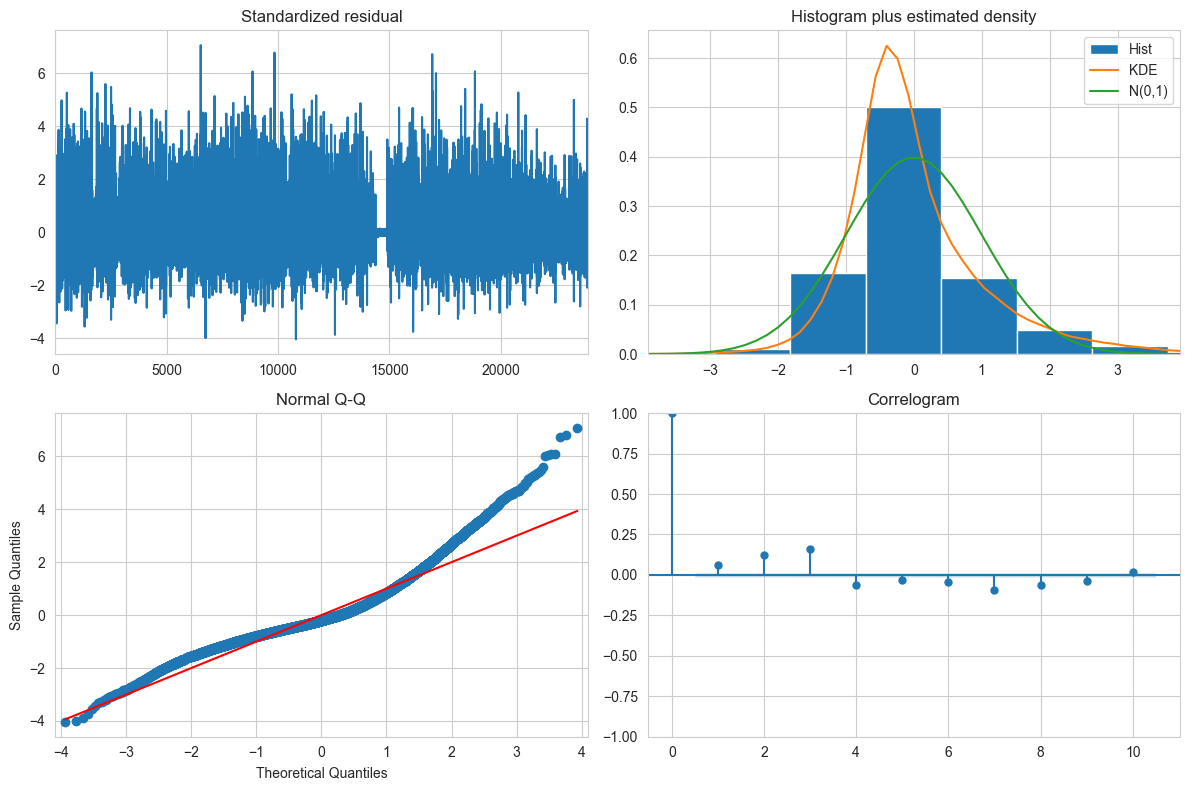

In [14]:
active_model = sarima_model if sarima_model is not None else arima_model
active_name = "SARIMA" if sarima_model is not None else "ARIMA"

print(f"Selected classical model: {active_name}")
active_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

## 7. Forecast Generation

Forecast across the **validation** set first as a sanity check, then
generate the final forecast across the **test** set for evaluation and
handoff to Member 3.

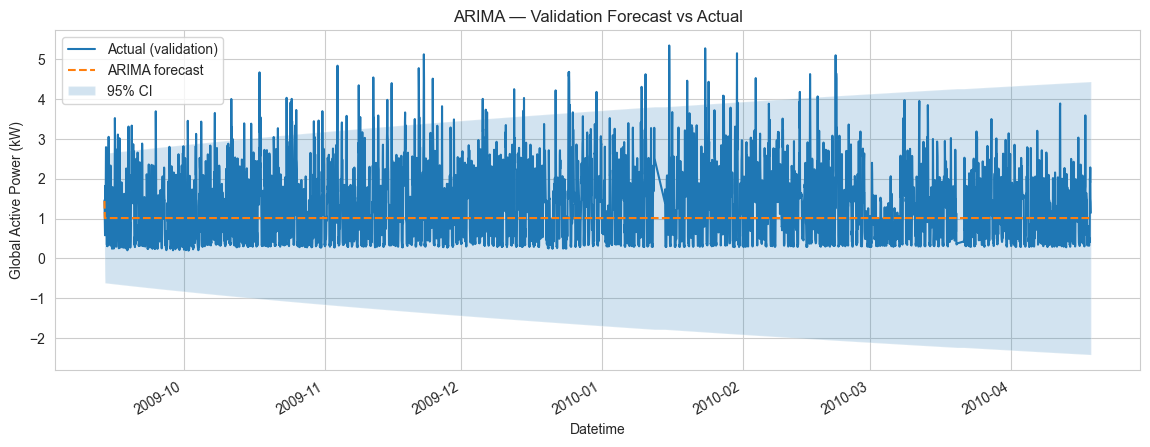

In [15]:
val_forecast, val_conf_int = forecast_series(active_model, n_periods=len(val), index=val.index)

fig, ax = plt.subplots(figsize=(14, 5))
val.plot(ax=ax, label="Actual (validation)")
val_forecast.plot(ax=ax, label=f"{active_name} forecast", linestyle="--")
ax.fill_between(val.index, val_conf_int[:, 0], val_conf_int[:, 1], alpha=0.2, label="95% CI")
ax.set_title(f"{active_name} — Validation Forecast vs Actual")
ax.set_ylabel("Global Active Power (kW)")
ax.legend()
plt.show()

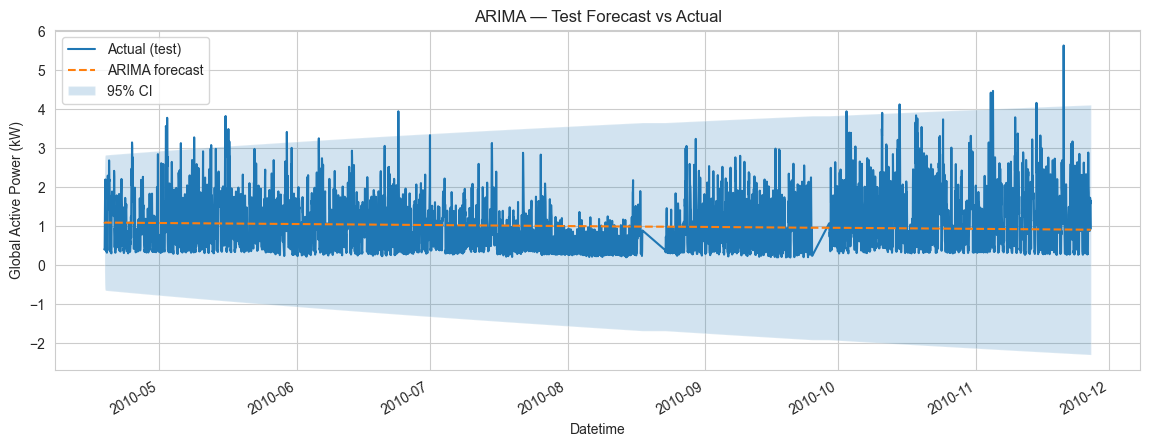

In [16]:
# Refit on train+val before forecasting the held-out test set,
# so the final test forecast benefits from all data prior to the test window.
train_val = pd.concat([train, val])

if active_name == "SARIMA":
    final_model = fit_sarima(train_val, m=SEASONAL_PERIOD, max_p=3, max_q=3, trace=False)
else:
    final_model = fit_arima(train_val, max_p=5, max_q=5, trace=False)

test_forecast, test_conf_int = forecast_series(final_model, n_periods=len(test), index=test.index)

fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual (test)")
test_forecast.plot(ax=ax, label=f"{active_name} forecast", linestyle="--")
ax.fill_between(test.index, test_conf_int[:, 0], test_conf_int[:, 1], alpha=0.2, label="95% CI")
ax.set_title(f"{active_name} — Test Forecast vs Actual")
ax.set_ylabel("Global Active Power (kW)")
ax.legend()
plt.show()

## 8. Model Evaluation

Metrics: MAE, RMSE, MAPE, R² — matching the metric set Member 1 uses for
the regression models, so results merge cleanly into Member 3's comparison
table.

In [17]:
test_metrics = evaluate_forecast(test, test_forecast)
test_metrics

{'MAE': 0.5949547690699665,
 'RMSE': 0.7164483291944244,
 'MAPE': 101.2128179551654,
 'R2': -0.019442784244970923}

### Actual vs Predicted

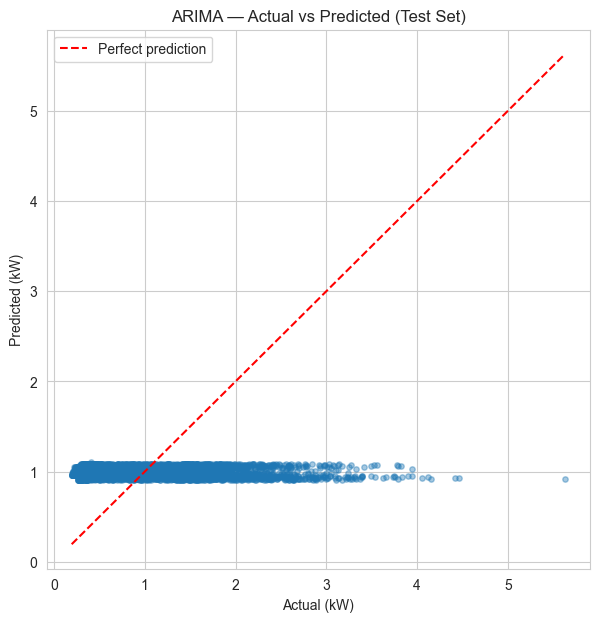

In [18]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(test, test_forecast, alpha=0.4, s=15)
lims = [min(test.min(), test_forecast.min()), max(test.max(), test_forecast.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual (kW)")
ax.set_ylabel("Predicted (kW)")
ax.set_title(f"{active_name} — Actual vs Predicted (Test Set)")
ax.legend()
plt.show()

### Residual / Error Analysis

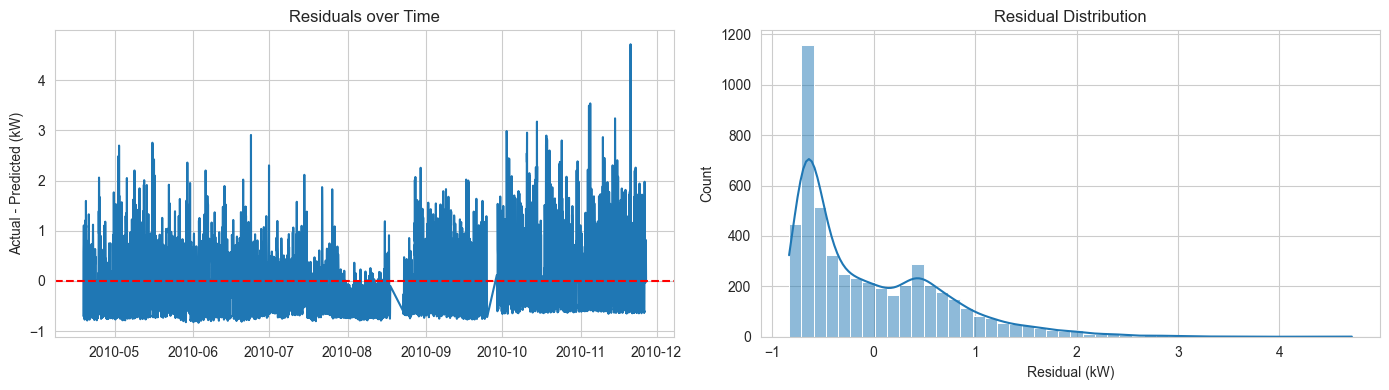

Mean residual: -0.0409 kW  (should be close to 0 if unbiased)
Residual std:  0.7153 kW


In [19]:
resid = residuals(test, test_forecast)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(resid.index, resid.values)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals over Time")
axes[0].set_ylabel("Actual - Predicted (kW)")

sns.histplot(resid, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (kW)")

plt.tight_layout()
plt.show()

print(f"Mean residual: {resid.mean():.4f} kW  (should be close to 0 if unbiased)")
print(f"Residual std:  {resid.std():.4f} kW")

### High-Demand Period Error Analysis

Evaluates forecast accuracy specifically on the top 10% highest-demand
hours in the test set. This matters because average error can look fine
while the model still performs poorly exactly when peak-demand accuracy is
most operationally important.

In [20]:
peak_analysis = high_demand_error_analysis(test, test_forecast, top_quantile=0.90)
peak_analysis

{'threshold': 1.9299600000000035,
 'n_high_demand_points': 513,
 'metrics': {'MAE': 1.4822808410965802,
  'RMSE': 1.5661329842578098,
  'MAPE': 58.72433073627003,
  'R2': -9.004790880537579}}

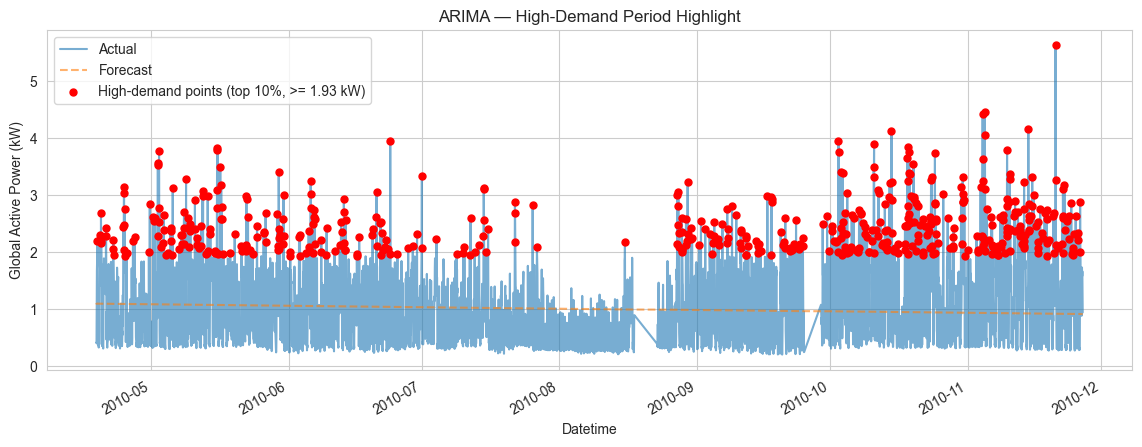

In [21]:
threshold = peak_analysis["threshold"]
high_mask = test >= threshold

fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual", alpha=0.6)
test_forecast.plot(ax=ax, label="Forecast", alpha=0.6, linestyle="--")
ax.scatter(test.index[high_mask], test[high_mask], color="red", s=25,
           label=f"High-demand points (top 10%, >= {threshold:.2f} kW)", zorder=5)
ax.set_title(f"{active_name} — High-Demand Period Highlight")
ax.set_ylabel("Global Active Power (kW)")
ax.legend()
plt.show()

## 9. Summary and Handoff to Member 3

Save the final model, the test-set predictions, and the metrics so Member 3
can drop them straight into the group comparison table.

In [22]:
summary = {
    "model_family": "classical_time_series",
    "selected_model": active_name,
    "order": list(final_model.order),
    "seasonal_order": list(final_model.seasonal_order) if active_name == "SARIMA" else None,
    "seasonal_period": SEASONAL_PERIOD,
    "differencing_order_d": d,
    "seasonality_strength": strength,
    "split": split_info,
    "test_metrics": test_metrics,
    "high_demand_metrics": peak_analysis,
}
summary

{'model_family': 'classical_time_series',
 'selected_model': 'ARIMA',
 'order': [1, 1, 3],
 'seasonal_order': None,
 'seasonal_period': 24,
 'differencing_order_d': 0,
 'seasonality_strength': 0.12748628432555376,
 'split': {'train': {'n_obs': 23899,
   'start': '2006-12-16 20:00:00',
   'end': '2009-09-13 12:00:00'},
  'val': {'n_obs': 5121,
   'start': '2009-09-13 13:00:00',
   'end': '2010-04-18 15:00:00'},
  'test': {'n_obs': 5122,
   'start': '2010-04-18 16:00:00',
   'end': '2010-11-26 21:00:00'}},
 'test_metrics': {'MAE': 0.5949547690699665,
  'RMSE': 0.7164483291944244,
  'MAPE': 101.2128179551654,
  'R2': -0.019442784244970923},
 'high_demand_metrics': {'threshold': 1.9299600000000035,
  'n_high_demand_points': 513,
  'metrics': {'MAE': 1.4822808410965802,
   'RMSE': 1.5661329842578098,
   'MAPE': 58.72433073627003,
   'R2': -9.004790880537579}}}

In [23]:
save_model(final_model, f"../models/{active_name.lower()}_model.pkl")

save_predictions(
    test.index,
    test,
    {f"{active_name.lower()}_pred": test_forecast},
    "../reports/classical_timeseries_predictions.csv",
)

save_metrics(summary, "../reports/classical_timeseries_metrics.json")

print("Saved:")
print(f"  ../models/{active_name.lower()}_model.pkl")
print("  ../reports/classical_timeseries_predictions.csv")
print("  ../reports/classical_timeseries_metrics.json")

Saved:
  ../models/arima_model.pkl
  ../reports/classical_timeseries_predictions.csv
  ../reports/classical_timeseries_metrics.json


## 10. Conclusion

Fill in after running against the real dataset:

- Whether SARIMA outperformed plain ARIMA, and by how much.
- Final chosen order (p, d, q) and seasonal order (P, D, Q, m).
- Test-set MAE / RMSE / MAPE / R², and how they compare to the baseline and
  regression models from Member 1.
- Any weaknesses observed in the high-demand period analysis.
- Anything flagged for Member 3 (e.g. split boundaries used, resampling
  decision) that must stay consistent across the group's final comparison.